# Meta-Harness: Observability and Optimization Metrics

In this notebook, you'll learn how to:
1. Read the evolutionary logs generated by Kota's **Meta-Harness**
2. Interpret the **Energy Score** (a proxy for computational latency and token burn)
3. Plot the **Pareto Optimization Frontier** to visualize the tradeoff between agent competence and efficiency
4. Make data-driven decisions on which Agent Mutants to deploy to production

## Setup

Kota's Meta-Harness mutates the agent's prompts and tests them against standard benchmarks, logging the results to `evolution_summary.jsonl`.

Let's check if this file exists from a previous run. If not, we will simulate a multi-generational evolution log so you can visualize the mathematics.

In [4]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

LOG_PATH = "../meta_search/logs/evolution_summary.jsonl"

if not os.path.exists(LOG_PATH):
    print(f"Log not found at {LOG_PATH}. Simulating evolutionary data...")
    os.makedirs(os.path.dirname(LOG_PATH), exist_ok=True)

    # Simulate 50 agent mutants across 5 generations
    # Generation 1 starts poor. Generation 5 converges on better pass rates and lower energy.
    np.random.seed(42)
    mock_logs = []
    for gen in range(1, 6):
        for i in range(10):
            # As generations increase, pass rate goes up and energy goes down
            pass_rate = np.clip(
                np.random.normal(loc=0.3 + (gen * 0.1), scale=0.1), 0.0, 1.0
            )
            energy = np.clip(
                np.random.normal(loc=12000 - (gen * 1000), scale=2000), 1000, 20000
            )

            mock_logs.append(
                {
                    "mutant_id": f"gen_{gen}_mutant_{i}",
                    "generation": gen,
                    "pass_rate": round(pass_rate, 3),
                    "energy_score": int(energy),
                    "timestamp": "2026-07-05T00:00:00Z",
                }
            )

    with open(LOG_PATH, "w") as f:
        for entry in mock_logs:
            f.write(json.dumps(entry) + "\n")
    print("Synthetic evolution log generated!")
else:
    print("Loaded existing Meta-Harness evolution log.")

Loaded existing Meta-Harness evolution log.


## Visualizing the Evolution

We can load this JSONL file directly into a Pandas DataFrame and view the raw metrics of the various mutants.

In [5]:
df = pd.read_json(LOG_PATH, lines=True)
display(
    df.sort_values(by=["pass_rate", "energy_score"], ascending=[False, True]).head(10)
)

,mutant_id,generation,pass_rate,energy_score,timestamp
41,gen_5_mutant_1,5,0.948,5963,2026-07-05 00:00:00+00:00
43,gen_5_mutant_3,5,0.892,7657,2026-07-05 00:00:00+00:00
48,gen_5_mutant_8,5,0.830,7522,2026-07-05 00:00:00+00:00
45,gen_5_mutant_5,5,0.810,8937,2026-07-05 00:00:00+00:00
49,gen_5_mutant_9,5,0.801,6530,2026-07-05 00:00:00+00:00
32,gen_4_mutant_2,4,0.781,10712,2026-07-05 00:00:00+00:00
40,gen_5_mutant_0,5,0.778,7714,2026-07-05 00:00:00+00:00
47,gen_5_mutant_7,5,0.761,4072,2026-07-05 00:00:00+00:00
44,gen_5_mutant_4,5,0.747,8026,2026-07-05 00:00:00+00:00
34,gen_4_mutant_4,4,0.736,6709,2026-07-05 00:00:00+00:00


## The Pareto Optimization Frontier

A perfect agent has a **Pass Rate of 1.0** (solves every problem) and an **Energy Score of 0** (instantaneous, zero tokens).

In reality, making an agent smarter (increasing pass rate) usually requires adding complex rules to the system prompt (increasing tokens) or giving it more 'thinking' steps (increasing latency). This tradeoff creates a **Pareto Frontier**.

Let's plot it.

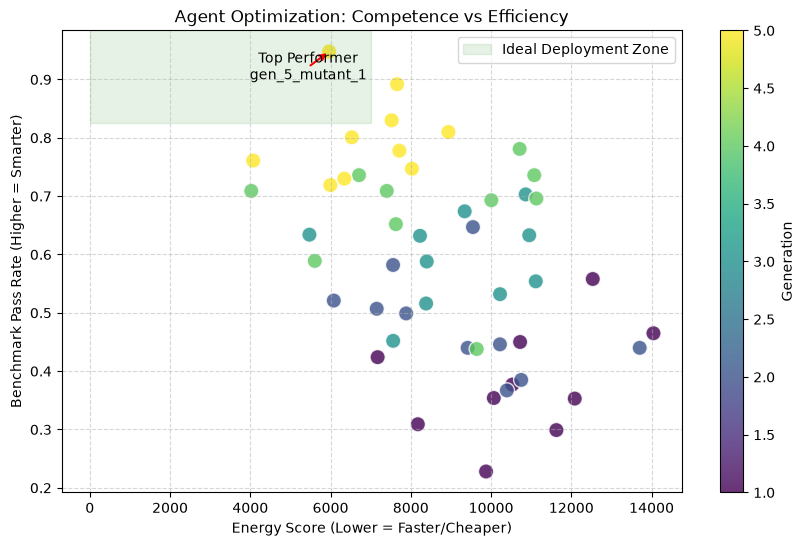

In [6]:
plt.figure(figsize=(10, 6))

# Scatter plot colored by generation
scatter = plt.scatter(
    df["energy_score"],
    df["pass_rate"],
    c=df["generation"],
    cmap="viridis",
    s=120,
    alpha=0.8,
    edgecolors="w",
)

plt.colorbar(scatter, label="Generation")

# Highlight the best agent
best_idx = df["pass_rate"].idxmax()
best_agent = df.loc[best_idx]
plt.annotate(
    f"Top Performer\n{best_agent['mutant_id']}",
    (best_agent["energy_score"], best_agent["pass_rate"]),
    textcoords="offset points",
    xytext=(-15, -20),
    ha="center",
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
)

plt.title("Agent Optimization: Competence vs Efficiency")
plt.xlabel("Energy Score (Lower = Faster/Cheaper)")
plt.ylabel("Benchmark Pass Rate (Higher = Smarter)")
plt.grid(True, linestyle="--", alpha=0.5)

# Add a region highlight for the "Ideal Zone"
plt.axvspan(
    0, 7000, ymin=0.8, ymax=1.0, color="green", alpha=0.1, label="Ideal Deployment Zone"
)
plt.legend()

plt.show()

## Deciding the Rollout

When selecting an agent for production from the Human-in-the-Loop gateway, you must look at this plot. 

If an agent achieves an 85% pass rate but has an energy score of `25000` (meaning it bloated the context window or got stuck in infinite loops), it might cost too much to run locally on an 8GB Mac. Alternatively, an agent with an 82% pass rate but an energy score of `6000` is vastly superior for deployment.


## Summary


In this notebook, you:

- Loaded the evolutionary metrics output directly by the `meta_harness.py` loop.
- Plotted the **Pareto Frontier** mapping out the tradeoff between reasoning accuracy (Pass Rate) and execution cost (Energy Score).
- Learned how to visually identify the top-performing mutants for production deployment in a local, resource-constrained environment.